In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import os

def process_and_plot_retired_projects(prefix, smoothing_sigma=2, min_months=1):
    # Construct filenames based on prefix
    static_file = f'{prefix}_inferences.csv'
    monthwise_file = f'{prefix}_monthwise_inferences.csv'
    
    # Load data
    df_static = pd.read_csv(static_file)
    df_monthwise = pd.read_csv(monthwise_file)
    
    # Merge data
    merged_df = pd.merge(
        df_monthwise,
        df_static,
        on=['project', 'train_strategy', 'model_arch'],
        suffixes=('_per_month', '_static')
    )
    
    # Filter projects with more than `min_months`
    project_month_counts = merged_df.groupby('project')['month'].nunique()
    long_projects = project_month_counts[project_month_counts > min_months].index
    filtered_df = merged_df[merged_df['project'].isin(long_projects)]
    
    # Keep only retired-retired projects
    final_df = filtered_df[
        (filtered_df['prediction_static'] == 'retired') |
        (filtered_df['target_static'] == 'retired')
    ]
    
    print(f"[{prefix}] Number of long, retired projects:", final_df['project'].nunique())

    # Create output folder
    output_dir = f'plots/{prefix}'
    os.makedirs(output_dir, exist_ok=True)

    # Plot each project
    for project_name, group in final_df.groupby('project'):
        plt.figure(figsize=(8, 4))
        
        group = group.sort_values('month')
        months = group['month'].values
        preds = group['prediction_per_month'].values
        smoothed_preds = gaussian_filter1d(preds, sigma=smoothing_sigma)

        plt.plot(months, preds, marker='o', color='gray', alpha=0.4, label='Original')
        plt.plot(months, smoothed_preds, color='blue', linewidth=2, label='Smoothed')

        plt.title(f"Month-wise Predictions for {project_name}")
        plt.xlabel("Month")
        plt.ylabel("Prediction Value")
        plt.ylim(0, 1)
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        
        # Save with prefix in filename
        plt.savefig(f'{output_dir}/{prefix}_{project_name}_prediction_curve.png')
        plt.close()


# ✅ Run for multiple prefixes
for prefix in ['apache', 'eclipse', 'osgeo', 'github']:
    process_and_plot_retired_projects(prefix)


[apache] Number of long, retired projects: 64
[eclipse] Number of long, retired projects: 12
[osgeo] Number of long, retired projects: 9
[github] Number of long, retired projects: 16


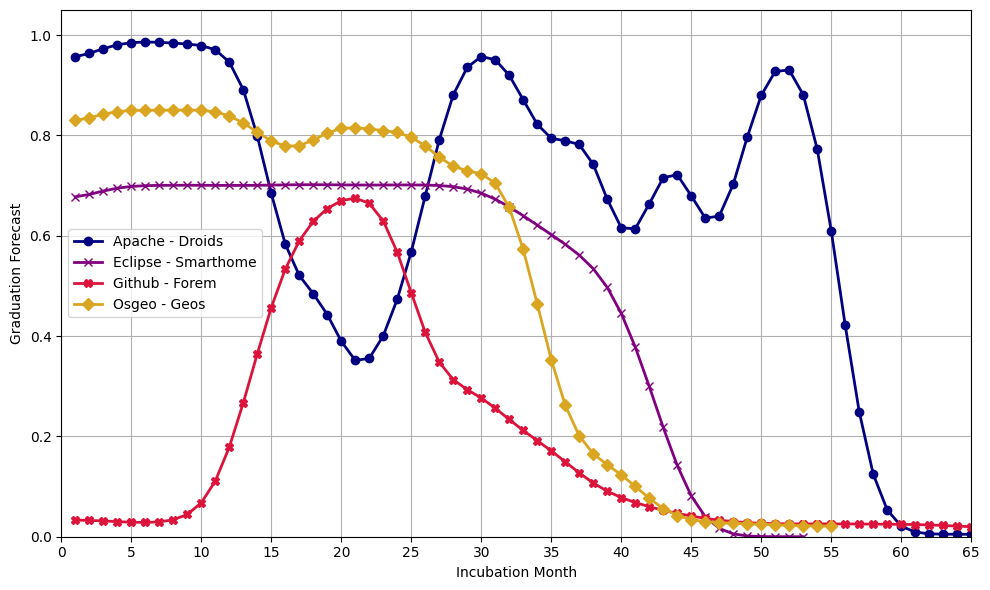

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# Mapping of foundation → project
foundation_projects = {
    'apache': 'droids',
    'eclipse': 'SmartHome',
    'github': 'forem',
    'osgeo': 'geos'
}

# Distinct colors and markers
styles = {
    'droids':    {'color': 'navy',     'marker': 'o'},
    'SmartHome': {'color': 'purple',   'marker': 'x'},
    'forem':     {'color': 'crimson',  'marker': 'X'},
    'geos':      {'color': 'goldenrod','marker': 'D'},
}

plt.figure(figsize=(10, 6))

# Load, smooth, and plot each
for foundation, project_name in foundation_projects.items():
    file = f'{foundation}_monthwise_inferences.csv'
    df = pd.read_csv(file)

    # Filter and sort
    project_df = df[df['project'] == project_name].sort_values('month')
    months = project_df['month'].values
    preds = project_df['prediction'].values
    smoothed_preds = gaussian_filter1d(preds, sigma=2)

    # Plot
    plt.plot(
        months,
        smoothed_preds,
        label=foundation.capitalize() + " - "+project_name.capitalize(),
        color=styles[project_name]['color'],
        marker=styles[project_name]['marker'],
        markersize=6,
        linewidth=2
    )

# Final plot settings

plt.xticks(range(0, 65 + 5, 5))
plt.xlim(0, 65)  
# plt.title("Graduation Likelihood vs Time")
plt.xlabel("Incubation Month")
plt.ylabel("Graduation Forecast")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('case_studies.png', dpi=300)

plt.show()
